# Identificación de eventos extremos
Analizar la relación existente entre precipitaciones extremas (>100 mm) con variables climaticas: Temperatura media anual, velocidad y dirección del viento medio anual, elevación y cobertura. El análisis es realizado con datos del 2022 en ciertas zonas de la región Andina


### Se importan librerias

In [1]:
# Importar librerias
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
from pyproj import CRS
import requests
from io import StringIO
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt
import matplotlib.ticker as mticker #Para que salgan las coordenas como enteras
import numpy as np
import seaborn as sns
import ee
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from pointpats import centrography
from matplotlib.patches import Ellipse
import libpysal
from matplotlib.patches import Polygon
from matplotlib.patches import Polygon as MplPolygon, Circle
from shapely.geometry import mapping
from descartes import PolygonPatch
from pointpats import distance_statistics, QStatistic, random, PointPattern
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm
from math import exp


### Descarga de datos
Se extrajo del IDEAM los datos de precipitación diaría, esta plataforma al no contar con un API, se montó los registros en la página Zenodo. El código descarga los datos de precipitación diaria mediante una API. 

In [2]:

ColumnasInteres = ["CodigoEstacion", "NombreEstacion", "Fecha", "Valor"]

# Crear carpeta de descarga
carpeta_descarga = os.path.join(os.getcwd(), "csv_descargados_estaciones")
os.makedirs(carpeta_descarga, exist_ok=True)

# Lista de Zenodo record IDs
record_ids = ["15514418", "15514388"]  # Puedes poner IDs distintos aquí
lista_df = []

for record_id in record_ids:
    api_url = f"https://zenodo.org/api/records/{record_id}"
    respuesta = requests.get(api_url)

    if respuesta.status_code != 200:
        print(f"Error al obtener metadata del ID {record_id}")
        continue

    data = respuesta.json()

    
    for archivo in data.get("files", []):
        nombre = archivo["key"]
        enlace = archivo["links"]["self"]

        if nombre.endswith(".csv"):
            print(f"Descargando: {nombre} desde {enlace}")
            r = requests.get(enlace)
            if r.status_code == 200:
                ruta_local = os.path.join(carpeta_descarga, nombre)
                with open(ruta_local, "wb") as f:
                    f.write(r.content)

                # Leer el CSV directamente desde el contenido de la respuesta
                df = pd.read_csv(StringIO(r.text))
                columnas_validas = [col for col in ColumnasInteres if col in df.columns]
                df_filtrado = df[columnas_validas].copy()
                lista_df.append(df_filtrado)
            else:
                print(f"Error al descargar {nombre}: {r.status_code}")

# Procesar archivos descargados
if lista_df:
    df_total = pd.concat(lista_df, ignore_index=True)
    df_total["Fecha"] = pd.to_datetime(df_total["Fecha"], errors="coerce")
    df_2022 = df_total[df_total["Fecha"].dt.year == 2022]
    grupos_2022 = dict(tuple(df_2022.groupby("CodigoEstacion")))
    print(f"Archivos descargados en: {carpeta_descarga}")
else:
    print("No se descargaron archivos válidos.")




Descargando: Santander9.csv desde https://zenodo.org/api/records/15514419/files/Santander9.csv/content
Descargando: Santander1.csv desde https://zenodo.org/api/records/15514419/files/Santander1.csv/content
Descargando: Santander8.csv desde https://zenodo.org/api/records/15514419/files/Santander8.csv/content
Descargando: VC5.csv desde https://zenodo.org/api/records/15514419/files/VC5.csv/content
Descargando: VC2.csv desde https://zenodo.org/api/records/15514419/files/VC2.csv/content
Descargando: Tolima6.csv desde https://zenodo.org/api/records/15514419/files/Tolima6.csv/content
Descargando: VC1.csv desde https://zenodo.org/api/records/15514419/files/VC1.csv/content
Descargando: Tolima1.csv desde https://zenodo.org/api/records/15514419/files/Tolima1.csv/content
Descargando: Tolima3.csv desde https://zenodo.org/api/records/15514419/files/Tolima3.csv/content
Descargando: VC4.csv desde https://zenodo.org/api/records/15514419/files/VC4.csv/content
Descargando: NS4.csv desde https://zenodo.or

### Filtrado de los datos
* Se filtra cada archivo para el año 2022
* Se excluyen del análisis las estaciones que carecen de mas del 10% de los datos
* Se guarda en un dt los años en los que hubo eventos con precipitación mayor al umbral
* Se guarda en un dt los años en los que no hubo eventos con precipitación mayor al umbral
* Para estos datos se encontró una relación de ocurrencias vs. no ocurrencias de 1:4



 Estaciones usadas en el análisis 


11070030: 365
11075020: 364
11110020: 360
12010110: 365
12010170: 365
12030010: 365
12030020: 365
16010020: 365
16010110: 365
16020250: 365
16030030: 365
16030080: 365
16030100: 364
16050100: 364
16055010: 365
16055040: 364
21010140: 365
21025030: 350
21030080: 364
21040030: 362
21050250: 365
21050290: 337
21055030: 365
21057060: 330
21060100: 340
21100080: 365
21110180: 356
21110290: 364
21130040: 339
21130110: 364
21130180: 361
21145070: 356
21147050: 362
21160030: 363
21160040: 363
21160050: 365
21160130: 360
21160160: 364
21165010: 362
21170020: 343
21180160: 329
21185080: 362
21190410: 365
21200160: 365
21200620: 358
21201060: 337
21202160: 365
21205660: 330
21205920: 364
21205940: 365
21205980: 365
21206280: 365
21220040: 365
21250070: 360
21250500: 356
21255090: 355
21255170: 363
22020030: 349
22020070: 343
22050060: 365
22060100: 363
22070010: 364
23020100: 365
23040030: 362
23050230: 365
23050250: 358
23055040: 365
23060260: 363
23060370:

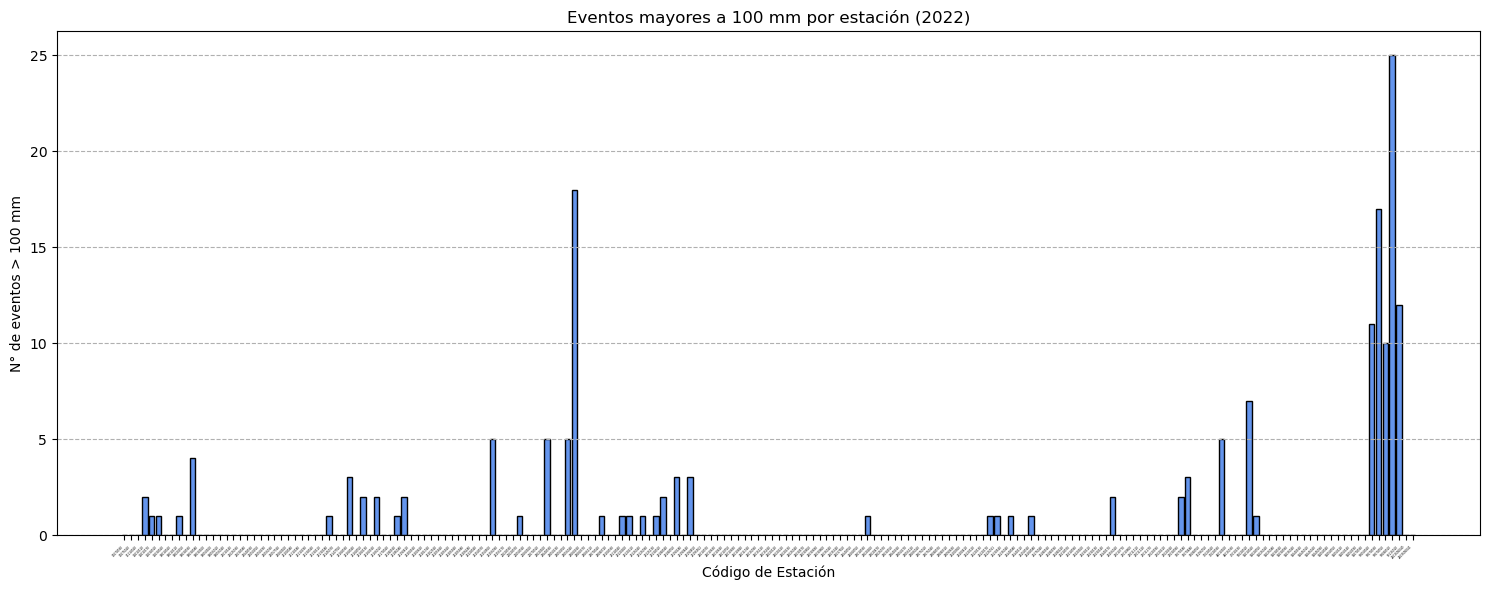

In [3]:
Umbral = 100
ruta_coord= carpeta_descarga

# Se busca en esta carpeta todos los archivos .csv
archivos_csv = glob.glob(os.path.join(carpeta_descarga, "*.csv"))

# Se leen los archivos
lista_df = [pd.read_csv(f) for f in archivos_csv] 

# Se unen en un solo dataframe la información
df_total = pd.concat(lista_df, ignore_index=True)

# Se filtra solo las columnas de interés
df_filtrado = df_total[ColumnasInteres].copy()

# Extraer solo datos del 2022: Año niña
df_filtrado["Fecha"] = pd.to_datetime(df_filtrado["Fecha"])
df_2022 = df_filtrado[df_filtrado["Fecha"].dt.year == 2022]
grupos_2022 = dict(tuple(df_2022.groupby("CodigoEstacion")))

#Años con 10% de datos faltantes
grupos_filtrados = {codigo: df for codigo, df in grupos_2022.items() if len(df) >= 328}


print("\n\n Estaciones usadas en el análisis \n\n")

for CodigoEstacion, df in grupos_filtrados.items():
    print(f"{CodigoEstacion}: {len(df)}")


# Crear carpeta de salida
doc_salida = "Resultados_Valores_Mayores_Umbra"
os.makedirs(doc_salida, exist_ok=True)


# Extraer eventos extremos
eventos_extremos = []

# Filtrar valores mayores a Umbral
for codigo, df in grupos_filtrados.items():
   
    df_mayores_Umbral = df[df["Valor"] >= Umbral].copy()
    df_mayores_Umbral["CodigoEstacion"] = codigo
    eventos_extremos.append(df_mayores_Umbral[["Fecha", "Valor", "CodigoEstacion"]])

# Concatenar todos los eventos extremos en un solo DataFrame    
df_eventos = pd.concat(eventos_extremos, ignore_index=True)
print("\n\n muestra de eventos \n\n",df_eventos.head(5))

df_eventos.to_csv(os.path.join(doc_salida, "eventos_mayores_umbral_por_estacion.csv"), index=False)
   
# Contar número de eventos por estación para la gráfica
conteo_eventos = {}
for CodigoEstacion, df in grupos_filtrados.items():
        num_eventos = (df["Valor"] > Umbral).sum()
        conteo_eventos[CodigoEstacion] = num_eventos


# Extraer estaciones sin esos eventos extremos (valores por debajo del umbral)
estaciones_sin_eventos_extremos = []

for codigo, df in grupos_filtrados.items():
    if df["Valor"].max() < Umbral:
        df = df.copy()
        df["CodigoEstacion"] = codigo
        estaciones_sin_eventos_extremos.append(df[["CodigoEstacion"]])

# Concatenar todos los no eventos en un solo DataFrame    
df_no_eventos = pd.concat(estaciones_sin_eventos_extremos, ignore_index=True)
print("\n\nmuestra de estaciones sin evento \n\n", df_no_eventos.head(5))

# Guardar los no eventos también
df_no_eventos.to_csv(os.path.join(doc_salida, "estaciones_sin_eventos_extremos.csv"), index=False)


# Convertir a listas para graficar
estaciones = list(map(str, conteo_eventos.keys()))
eventos = list(conteo_eventos.values())

# Graficar
plt.figure(figsize=(15, 6))
plt.bar(estaciones, eventos, color="cornflowerblue", edgecolor="black")
plt.xlabel("Código de Estación")
plt.ylabel(f"N° de eventos > {Umbral} mm")
plt.title(f"Eventos mayores a {Umbral} mm por estación (2022)")
plt.xticks(rotation=45, ha="right",fontsize=2)
plt.grid(axis="y", linestyle="--", alpha=1)
plt.tight_layout()
plt.show()

### Asignación de coordenadas
Para el análisis espacial se crean geodataframes de estas estaciones. Para esto se recurrió al catalogo de estaciones del IDEAM en CSV, el cual cuenta con las coordenadas de cada una de las estaciones. Asimismo, se garantizó que los datos tuvieran una proyección 9377 mediante un procesamiento en QGIS. 

In [4]:

# Crear carpeta de descarga
carpeta_descarga2 = os.path.join(os.getcwd(), "coords_estaciones")
os.makedirs(carpeta_descarga2, exist_ok=True)

# Zenodo record IDs
record_id = "15514435"  # Puedes poner IDs distintos aquí
lista_df = []
api_url = f"https://zenodo.org/api/records/{record_id}"
respuesta = requests.get(api_url)

record = respuesta.json()
for file in record['files']:
    if "CNE_IDEAM.csv" in file['key']:  # Ajusta según el nombre real
        url_descarga = file['links']['self']
        ruta_csv = os.path.join(carpeta_descarga2, file['key'])
        with requests.get(url_descarga, stream=True) as r:
            with open(ruta_csv, 'wb') as f:
                f.write(r.content)


ruta_csv = ruta_csv = os.path.join(carpeta_descarga2, "CNE_IDEAM.csv")
df_coord = pd.read_csv(ruta_csv)

#El código se pasa a entero para evitar errores
df_coord["Codigo"] = pd.to_numeric(df_coord["CODIGO"], errors="coerce")

#Se buscan las estaciones con eventos extremos
estaciones_eventos = df_eventos["CodigoEstacion"].unique()
estaciones_no_eventos = df_no_eventos["CodigoEstacion"].unique()

#Unir eventos extremos con coordenadas
df_eventos_coord = df_eventos.merge(df_coord, left_on="CodigoEstacion", right_on="Codigo")
df_no_eventos_coord = df_no_eventos.merge(df_coord, left_on="CodigoEstacion", right_on="Codigo")


#Se crea geometría y geodataframe
geometry = [Point(xy) for xy in zip(df_eventos_coord["X"], df_eventos_coord["Y"])]
gdf_eventos = gpd.GeoDataFrame(df_eventos_coord[["Fecha", "Valor", "CodigoEstacion"]], geometry=geometry)
gdf_eventos.set_crs(epsg=9377, inplace=True) 

geometry = [Point(xy) for xy in zip(df_no_eventos_coord["X"], df_no_eventos_coord["Y"])]
gdf_no_eventos = gpd.GeoDataFrame(df_no_eventos_coord[["CodigoEstacion"]], geometry=geometry)
gdf_no_eventos.set_crs(epsg=9377, inplace=True) 
                                  
carpeta_salida = "Resultados_Valores_Mayores_Umbral"
os.makedirs(carpeta_salida, exist_ok=True)

ruta_salida = os.path.join(carpeta_salida,"eventos_extremos_con_geometry.csv")
gdf_eventos.to_csv(ruta_salida, index=False)

ruta2_salida = os.path.join(carpeta_salida,"estaciones_sin_extremos_con_geometry.csv")
gdf_no_eventos.to_csv(ruta2_salida, index=False)


## Descarga de zonas de intéres
Se descarga la geometría de la zona de interés, esto servirá en un futuro cuando se quiera hacer un filtro por departamento

Descargando: ZonaAndina.dbf
Descargando: ZonaAndina.shx
Descargando: ZonaAndina.prj
Descargando: ZonaAndina.cpg
Descargando: ZonaAndina.shp
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   REGION    5 non-null      object  
 1   geometry  5 non-null      geometry
dtypes: geometry(1), object(1)
memory usage: 212.0+ bytes


<Axes: >

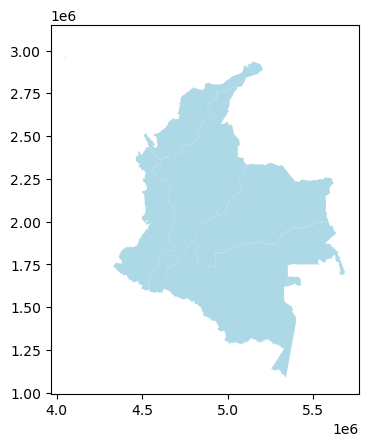

In [5]:
#Visualizar datos

record_id = "15529044"  # 
carpeta_destino = os.path.join(os.getcwd(), "Region_descargado")
os.makedirs(carpeta_destino, exist_ok=True)

# Construir URL del API
api_url = f"https://zenodo.org/api/records/{record_id}"
respuesta = requests.get(api_url)

if respuesta.status_code == 200:
    record = respuesta.json()
    
    for archivo in record.get("files", []):
        nombre_archivo = archivo["key"]
        
        # Filtrar extensiones típicas de shapefile
        if any(nombre_archivo.endswith(ext) for ext in [".shp", ".shx", ".dbf", ".prj", ".cpg", ".sbn", ".sbx"]):
            url_descarga = archivo["links"]["self"]
            ruta_local = os.path.join(carpeta_destino, nombre_archivo)
            print(f"Descargando: {nombre_archivo}")
            with requests.get(url_descarga, stream=True) as r:
                with open(ruta_local, 'wb') as f:
                    f.write(r.content)
else:
    print(f" Error al acceder al registro Zenodo: {respuesta.status_code}")

ruta_shp = os.path.join(carpeta_destino, "ZonaAndina.shp")  
DeptosCol = gpd.read_file(ruta_shp)
type(DeptosCol)
DeptosCol.info()
DeptosCol.head(2)
DeptosCol.plot(color="lightblue")

In [6]:
departamentos_destacados = [
    "ANDINA"
]

DeptosCol["grupo"] = DeptosCol["REGION"].apply(
    lambda x: "Foco" if x in departamentos_destacados else "Resto"
)


In [7]:
DeptosCol.head(10)

,REGION,geometry,grupo
0,AMAZONÍA,"POLYGON ((5591713.667 1991922.972, 5591944.662...",Resto
1,ANDINA,"POLYGON ((5111235.228 2843599.432, 5082331.957...",Foco
2,CARIBE,"MULTIPOLYGON (((5144923.23 2934928.088, 514495...",Resto
3,ORINOQUÍA,"POLYGON ((5256175.271 2342355.176, 5256266.907...",Resto
4,PACÍFICA,"POLYGON ((4519503.956 2519177.391, 4519616.85 ...",Resto


### Filtro espacial
Se filtran las estaciones según los departamentos que se quieren analizar. Anteriormente se clasificaron las zonas de interés.

In [8]:
#limitar los departamentos según los departamentos destacados
deptos_foco = DeptosCol[DeptosCol["REGION"].isin(departamentos_destacados)]

#Dejar solo los eventos del área de interés
Eventos = gpd.sjoin(gdf_eventos, deptos_foco, how="inner", predicate="intersects")
No_eventos = gpd.sjoin(gdf_no_eventos, deptos_foco, how="inner", predicate="intersects")
#Quitar columnas demás
GeoColumnas=["Fecha","Valor","CodigoEstacion","geometry"]
GeoColumnas2=["CodigoEstacion","geometry"]

Eventos = Eventos[GeoColumnas]
No_eventos = No_eventos[GeoColumnas2]

# Eliminar duplicados de estaciones (una geometría por estación no-evento)
No_eventos = No_eventos.drop_duplicates(subset="CodigoEstacion")

ruta_geojson = os.path.join(carpeta_salida, "eventos_extremos.geojson")
Eventos.to_file(ruta_geojson, driver="GeoJSON")
print("\n\n Eventos \n\n ",Eventos)

ruta_geojson2 = os.path.join(carpeta_salida, "eventos_no_extremos.geojson")
No_eventos.to_file(ruta_geojson2, driver="GeoJSON")
print("\n\n No Eventos \n\n ",No_eventos)



 Eventos 

          Fecha  Valor  CodigoEstacion                         geometry
5  2022-04-26  131.2        16010110   POINT (5045113.67 2399224.371)
6  2022-09-12  117.0        16030030  POINT (5033285.026 2498912.382)
7  2022-09-15  133.0        16030030  POINT (5033285.026 2498912.382)
8  2022-09-17  114.0        16030030  POINT (5033285.026 2498912.382)
9  2022-09-28  100.0        16030030  POINT (5033285.026 2498912.382)
..        ...    ...             ...                              ...
86 2022-04-24  135.0        37020030  POINT (5077239.608 2342474.535)
87 2022-04-30  130.0        37020030  POINT (5077239.608 2342474.535)
88 2022-07-08  116.0        37020030  POINT (5077239.608 2342474.535)
89 2022-10-01  101.0        37020030  POINT (5077239.608 2342474.535)
90 2022-10-07  130.0        37020030  POINT (5077239.608 2342474.535)

[84 rows x 4 columns]


 No Eventos 

         CodigoEstacion                         geometry
0            11070030  POINT (4650763.535 2281693

### Cantidad de eventos
Se crea un geodataframe con el número de eventos que tuvo cada estación que superó el umbral

In [9]:
#Reset index convierte en un dataframe estandar
frecuencias = Eventos['CodigoEstacion'].value_counts().reset_index() #Cuenta cuántas veces aparece ese código, añade los titulos
frecuencias.columns = ['CodigoEstacion', 'eventos']  # Renombrar columnas
geometrias = Eventos.groupby('CodigoEstacion')['geometry'].first().reset_index() #first toma el primer valor encontrado de Geomy para esa EST
FrecEventos = pd.merge(frecuencias, geometrias, on='CodigoEstacion')
FrecEventos = gpd.GeoDataFrame(FrecEventos, geometry='geometry')
print(FrecEventos.head(150))

    CodigoEstacion  eventos                         geometry
0         23055040       18  POINT (4779265.642 2157074.004)
1         37020030        5  POINT (5077239.608 2342474.535)
2         21250500        5  POINT (4769896.876 2102219.612)
3         23020100        5  POINT (4786820.828 2146612.991)
4         23050250        5   POINT (4790536.892 2174305.11)
5         16030030        5  POINT (5033285.026 2498912.382)
6         35070180        3  POINT (4971543.517 2095114.855)
7         21160030        3  POINT (4812728.701 2007531.013)
8         23190440        3  POINT (4966923.125 2354152.695)
9         23180050        3  POINT (4934048.447 2391359.368)
10        23120200        2  POINT (4880362.965 2280111.538)
11        27030090        2  POINT (4797032.253 2367188.171)
12        26240170        2  POINT (4729919.538 2394413.076)
13        23130010        2  POINT (4886092.236 2318105.756)
14        23125130        2  POINT (4910550.389 2245520.257)
15        23110040      

## Distribución de eventos
El sistema de coordenadas se pasa a EPSG 3857, ya que es el compatible con el basemap a usar

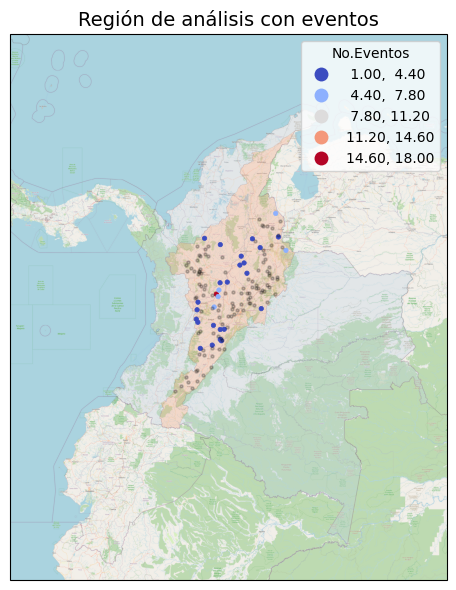

In [10]:
tiler = cimgt.OSM() #crear objeto basemap con OSM
mercator = tiler.crs #convierte a 3857
FrecEventos.set_crs(epsg=9377, inplace=True) 
No_eventos.set_crs(epsg=9377, inplace=True)
No_eventos_merc = No_eventos.to_crs(mercator)

DeptosCol_merc = DeptosCol.to_crs(mercator)
FrecEventos_merc = FrecEventos.to_crs(mercator)

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw={'projection': mercator})
ax.add_image(tiler, 8) # Nivel de zoom 8

# Colores de mapa
colores = {"Foco": "#F4A582", "Resto": "#BFD3E6"}  # pastel naranja y azul claro
DeptosCol_merc.plot(ax=ax, facecolor=DeptosCol_merc["grupo"].map(colores), alpha = 0.3,
                    edgecolor="gray", linewidth=0.1, transform=mercator)

FrecEventos_merc.plot(column='eventos', 
                     scheme='equal_interval',  # Esquema de cuantiles
                     markersize=10,      # Tamaño
                     cmap='coolwarm',    # Mapa de colores (rojo-amarillo-azul invertido)
                     linewidth=0.5,
                     legend=True,
                     legend_kwds={'title': 'No.Eventos', 'loc': 'upper right'},
                     marker = 'o', ax=ax,transform=mercator, alpha =1, facecolor ='auto') #alpha -> transparencia, 

No_eventos_merc.plot(
    ax=ax,
    color="black",
    markersize=5,
    label="Estaciones sin extremos",
    alpha=0.2,
    transform=mercator,
    marker='o', legend=True,legend_kwds={'title': 'No ext', 'loc': 'upper right'})

# Título
ax.set_title("Región de análisis con eventos", fontsize=14)
plt.tight_layout()
plt.show()


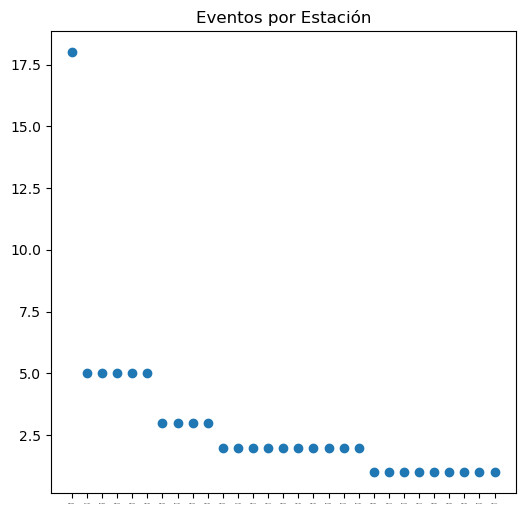

In [11]:
x0 = FrecEventos["CodigoEstacion"]
x = list(map(str, x0))
y = FrecEventos["eventos"]
fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title("Eventos por Estación", fontsize=12)
plt.xticks(fontsize=1) 
plt.yticks(fontsize=10) 
plt.scatter(x,y)
plt.show()

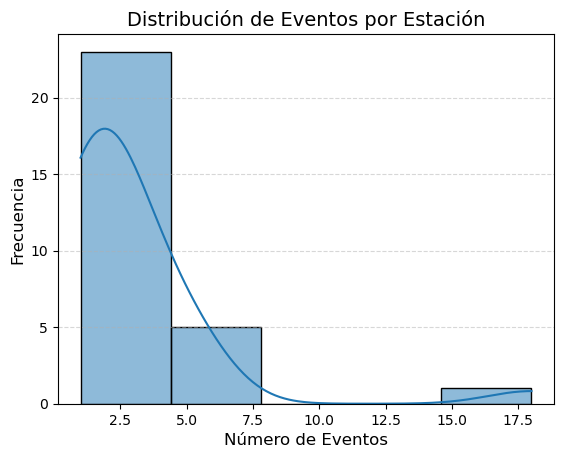

In [12]:
HistogramaEventos = sns.histplot(FrecEventos["eventos"], kde = True, bins = 5)   # Cálculo automático de bins (reglas de Sturges/Freedman-Diaconis) si no se indica
plt.title("Distribución de Eventos por Estación", fontsize=14)
plt.xlabel("Número de Eventos", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)

In [13]:
#Se convierte los puntos a 4326 que es lo que lee GEE
FrecEventos_4326 = FrecEventos.to_crs(epsg=4326)
FrecEventos_4326["lat"] = FrecEventos_4326.geometry.y
FrecEventos_4326["lon"] = FrecEventos_4326.geometry.x
FrecEventos_4326.head(3)

,CodigoEstacion,eventos,geometry,lat,lon
0,23055040,18,POINT (-74.99293 5.41829),5.418288,-74.992928
1,37020030,5,POINT (-72.30028 7.09889),7.098889,-72.300278
2,21250500,5,POINT (-75.07586 4.92189),4.921889,-75.075861


### Densidad espacial de eventos (Hexbin)

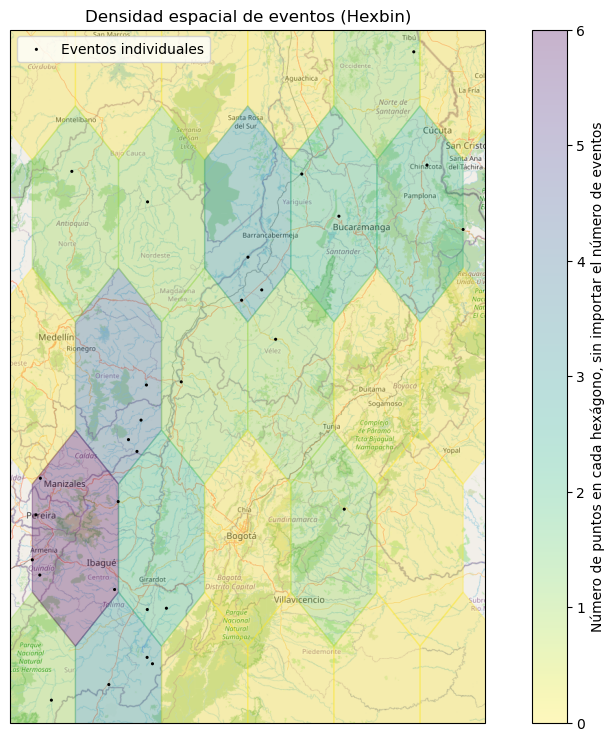

In [14]:
tiler = cimgt.OSM()
mercator = tiler.crs
FrecEventos_3857 = FrecEventos_4326.to_crs(mercator)

f, ax = plt.subplots(1, figsize=(12, 9), subplot_kw={'projection': mercator})

ax.add_image(tiler, 8, alpha=1)
ax.set_extent([
    FrecEventos_3857.geometry.x.min() - 20000,
    FrecEventos_3857.geometry.x.max() + 20000,
    FrecEventos_3857.geometry.y.min() - 20000,
    FrecEventos_3857.geometry.y.max() + 20000
], crs=mercator)

hb = ax.hexbin(
    FrecEventos_3857.geometry.x,   # primero longitud (x)
    FrecEventos_3857.geometry.y,   # luego latitud (y)
    gridsize=5, 
    linewidths=1,
    alpha=0.3, 
    cmap='viridis_r'
)

ax.scatter(
    FrecEventos_3857.geometry.x, 
    FrecEventos_3857.geometry.y,
    color='black',      # o el que prefieras
    edgecolor='none',  # borde blanco para destacar
    s=5, 
    alpha=1, 
    label='Eventos individuales'
)

plt.colorbar(hb, label='Número de puntos en cada hexágono, sin importar el número de eventos')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.legend()
plt.title('Densidad espacial de eventos (Hexbin)')
plt.show()

### Densidad espacial de eventos (KDE)

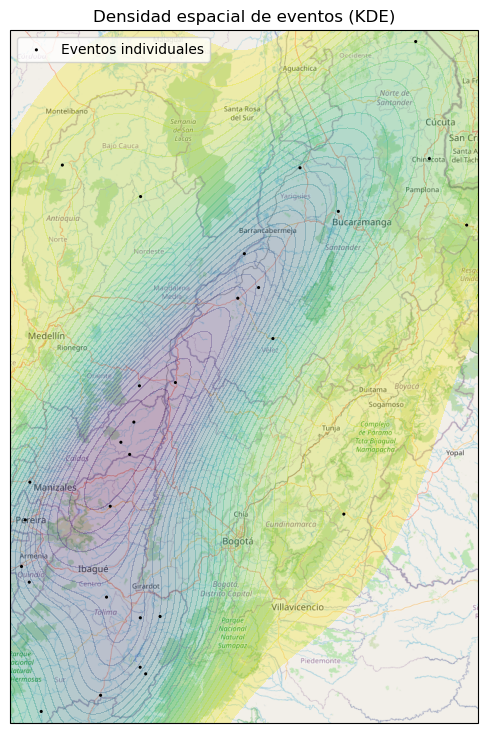

In [15]:
tiler = cimgt.OSM()
mercator = tiler.crs

FrecEventos_3857 = FrecEventos_4326.to_crs(mercator)

f, ax = plt.subplots(1, figsize=(12, 9), subplot_kw={'projection': mercator})

ax.add_image(tiler, 8, alpha=1)
ax.set_extent([
    FrecEventos_3857.geometry.x.min() - 10000,
    FrecEventos_3857.geometry.x.max() + 10000,
    FrecEventos_3857.geometry.y.min() - 10000,
    FrecEventos_3857.geometry.y.max() + 10000
], crs=mercator)

sns.kdeplot(
    x = FrecEventos_3857.geometry.x,   # primero longitud (x)
    y = FrecEventos_3857.geometry.y,   # luego latitud (y)
    levels=30, 
    fill=True,
    alpha=0.3, 
    cmap='viridis_r',
    ax = ax)

ax.scatter(
    FrecEventos_3857.geometry.x, 
    FrecEventos_3857.geometry.y,
    color='black',      # o el que prefieras
    edgecolor='none',  # borde blanco para destacar
    s=5, 
    alpha=1, 
    label='Eventos individuales',
    transform=mercator)


ax.legend()
ax.set_title('Densidad espacial de eventos (KDE)')
plt.show()

### Centografía + KDE

La discrepancia entre la media y la media se debe a la asimetría

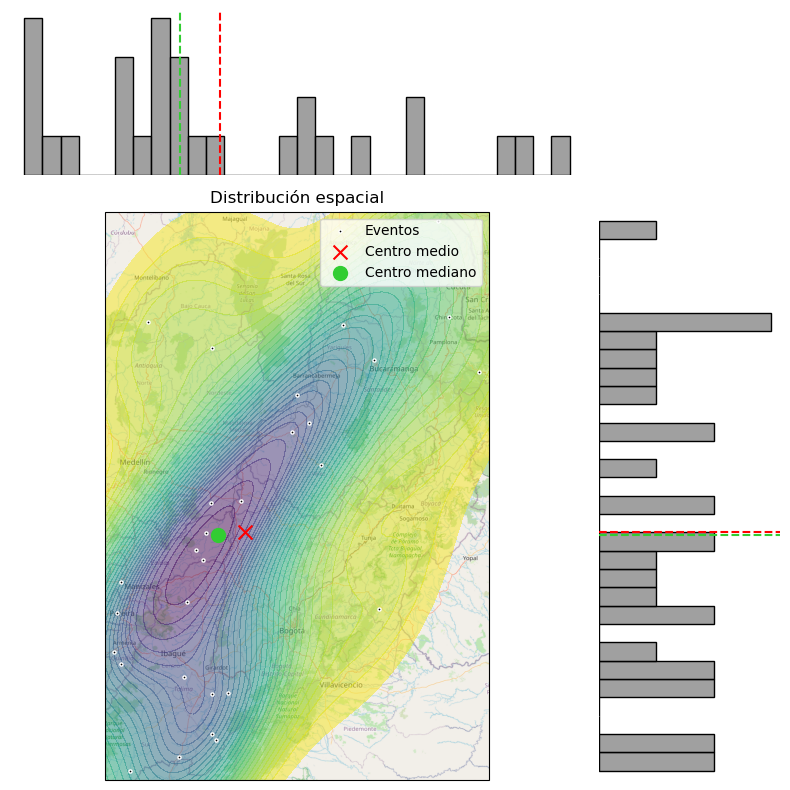

In [16]:
# 1. Preparar datos
tiler = cimgt.OSM()
mercator = tiler.crs
FrecEventos_3857 = FrecEventos_4326.to_crs(mercator)
coords = list(zip(FrecEventos_3857.geometry.x, FrecEventos_3857.geometry.y))


mean_center = centrography.mean_center(coords)
med_center = centrography.euclidean_median(coords)

x = FrecEventos_3857.geometry.x
y = FrecEventos_3857.geometry.y

# 2. Crear diseño tipo jointplot con 3 ejes: mapa + histogramas
fig = plt.figure(figsize=(8, 8))
gs = gridspec.GridSpec(4, 4)

# Ejes principales (mapa con cartopy)
ax_main = fig.add_subplot(gs[1:4, 0:3], projection=mercator)
ax_main.add_image(tiler, 8)
ax_main.set_extent([
    x.min() - 10000, x.max() + 10000,
    y.min() - 10000, y.max() + 10000
], crs=mercator)

# 3. Dibujo de puntos, KDE, centros
sns.kdeplot(
    x=x, y=y,
    fill=True, levels=30, alpha=0.5, cmap="viridis_r",
    ax=ax_main
)
ax_main.scatter(x, y, color='black', s=5, alpha=1, edgecolors='white', transform=mercator, label='Eventos')
ax_main.scatter(*mean_center, color='red', marker='x', s=100, transform=mercator, label='Centro medio')
ax_main.scatter(*med_center, color='limegreen', marker='o', s=100, transform=mercator, label='Centro mediano')
ax_main.legend(loc='upper right')
ax_main.set_title('Distribución espacial')

# 4. Histograma superior (x)
ax_histx = fig.add_subplot(gs[0, 0:3], sharex=ax_main)
sns.histplot(x=x, bins=30, ax=ax_histx, color='gray')
ax_histx.axvline(mean_center[0], color='red', linestyle='--')
ax_histx.axvline(med_center[0], color='limegreen', linestyle='--')
ax_histx.axis('off')

# 5. Histograma derecho (y)
ax_histy = fig.add_subplot(gs[1:4, 3], sharey=ax_main)
sns.histplot(y=y, bins=30, ax=ax_histy, color='gray')
ax_histy.axhline(mean_center[1], color='red', linestyle='--')
ax_histy.axhline(med_center[1], color='limegreen', linestyle='--')
ax_histy.axis('off')

plt.tight_layout()
plt.show()


### Dispersión: elipse estándar
Elipse trazada a partir de los datos que refleja tanto su centro como su dispersión.

en promedio las fotos se tomaron a una distancia de 194782.53506119046  m desde el centro, aunque en este caso no aplica tan así, en este caso no es tan buena medida de caracterización


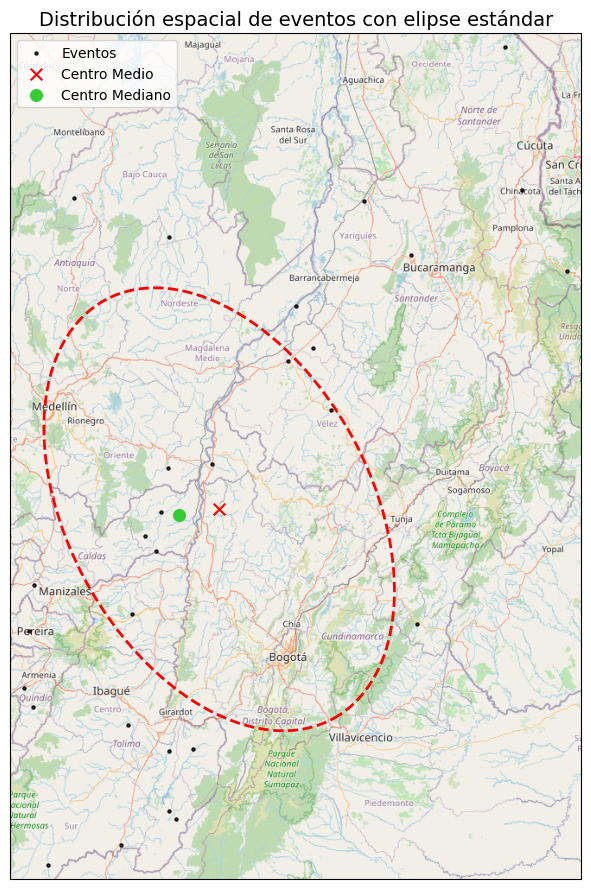

In [17]:
# Extraer coordenadas x, y
x = FrecEventos_3857.geometry.x
y = FrecEventos_3857.geometry.y
coords = list(zip(x, y))

# Calcular centros y parámetros de la elipse
mean_center = centrography.mean_center(coords)
med_center = centrography.euclidean_median(coords)
major, minor, rotation = centrography.ellipse(coords)

# Crear figura con mapa base
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': mercator})
ax.add_image(tiler, 8)

# Establecer extensión del mapa en torno a los puntos
buffer = 10000  # metros
ax.set_extent([
    x.min() - buffer,
    x.max() + buffer,
    y.min() - buffer,
    y.max() + buffer
], crs=mercator)

# Graficar puntos de eventos
ax.scatter(x, y, s=5, color='black', alpha=0.8, transform=mercator, label="Eventos")

# Graficar centros
ax.scatter(*mean_center, color='red', marker='x', s=70, label='Centro Medio', transform=mercator)
ax.scatter(*med_center, color='limegreen', marker='o', s=70, label='Centro Mediano', transform=mercator)

# Agregar elipse estándar
ellipse = Ellipse(
    xy=mean_center,
    width=major * 2,
    height=minor * 2,
    angle=np.degrees(rotation),
    edgecolor='red',
    facecolor='none',
    linestyle='--',
    linewidth=2
)

# Importante: añadir la elipse como patch con la transformación
ax.add_patch(ellipse)
ellipse.set_transform(mercator)  # Para que se dibuje correctamente en coordenadas del mapa

# Título y leyenda
ax.set_title("Distribución espacial de eventos con elipse estándar", fontsize=14)
ax.legend()
plt.tight_layout()
print("en promedio las fotos se tomaron a una distancia de", centrography.std_distance(coords)," m desde el centro, aunque en este caso no aplica tan así, en este caso no es tan buena medida de caracterización")
plt.show()

### Extensión: Convex hull
Forma convexa más ajustada que encierra los eventos. Por convexa, nos referimos a que la forma nunca “retrocede” sobre sí misma; no tiene depresiones, valles, crestas o agujeros. Todos sus ángulos interiores son menores de 180 grados. 

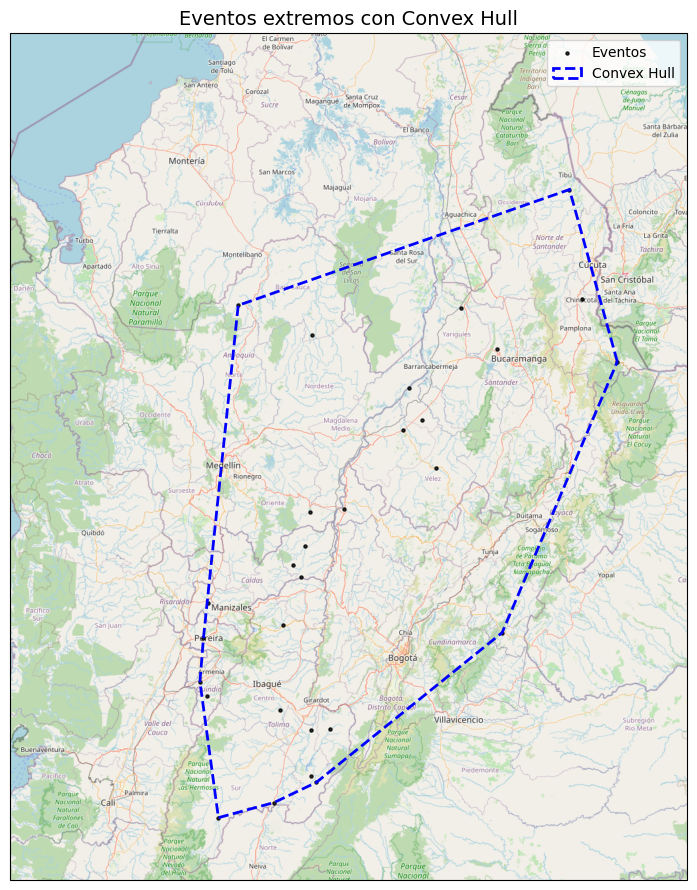

In [18]:
# Extraer coordenadas x, y
FrecEventos_3857 = FrecEventos_4326.to_crs(mercator)
x = FrecEventos_3857.geometry.x
y = FrecEventos_3857.geometry.y
coords = list(zip(x, y))

# Crear figura con mapa base
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': mercator})
ax.add_image(tiler, 8)

# Graficar puntos de eventos
ax.scatter(x, y, s=5, color='black', alpha=0.8, transform=mercator, label="Eventos")

#Convexhull
convex_hull_vertices = centrography.hull(coords)

# Crear y agregar el polígono del convex hull
hull_polygon = Polygon(convex_hull_vertices, closed=True,
                       facecolor='none', edgecolor='blue',
                       linewidth=2, linestyle='--', label='Convex Hull')

# IMPORTANTE: Asignar proyección
hull_polygon.set_transform(mercator)
ax.add_patch(hull_polygon)
    
# Ajustes finales
ax.set_title("Eventos extremos con Convex Hull", fontsize=14)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [19]:
# Extraer coordenadas x, y

#x = FrecEventos_3857.geometry.x
#y = FrecEventos_3857.geometry.y
#coords = list(zip(x, y))

## Crear figura con mapa base
#fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': mercator})
#ax.add_image(tiler, 8)

# Graficar puntos de eventos
#ax.scatter(x, y, s=5, color='black', alpha=0.8, transform=mercator, label="Eventos")

#xmin, ymin, xmax, ymax = FrecEventos_3857.total_bounds
##num_points = len(coords)
##random_x = np.random.uniform(xmin, xmax, num_points)
#random_y = np.random.uniform(ymin, ymax, num_points)
#ax.scatter(random_x, random_y, s=5, color='red', alpha=0.8, transform=mercator, label="random")

# Ajustes finales
#ax.set_title("Aleatoriedad y agrupamiento", fontsize=14)
##ax.legend(loc='upper right')
#plt.tight_layout()
#plt.show()

## Topografía: 
NASADEM es un reprocesamiento de datos SRTM, 
con mayor precisión gracias a la incorporación de datos auxiliares de 
los conjuntos de datos ASTER GDEM, ICESat GLAS y PRISM. Las mejoras de 
procesamiento más significativas incluyen la reducción de vacíos mediante un 
desdoblamiento de fase mejorado y el uso de datos ICESat GLAS para el control.

Se debe importar EE y luego autenticar con 
ee.Authenticate()
loggearse con la cuenta de GEE y escribir el código, en caso que no sea así, escribir en el cmd earthengine authenticate --force

In [20]:
try:
    ee.Initialize(project='my-project-analisis-geoesp')
    print("Google Earth Engine inicializado correctamente.")
except Exception as e:
    print(f"Error al inicializar Earth Engine: {e}")
    print("Asegúrate de que tus credenciales están configuradas y el project ID es correcto.")
    print("Si no lo has hecho, ejecuta 'earthengine authenticate' en tu terminal.")
    exit() # Salir si la inicialización falla


Google Earth Engine inicializado correctamente.


In [21]:
nasadem = ee.Image("NASA/NASADEM_HGT/001")

In [22]:
def get_elevation(lat, lon):
    point = ee.Geometry.Point([lon, lat])
    elev = nasadem.sample(region=point, scale=30).first()
    try:
        return elev.get("elevation").getInfo()
    except:
        return None

In [23]:
FrecEventos_4326["elevacion"] = FrecEventos_4326.apply(lambda row: get_elevation(row.lat, row.lon), axis=1)
print("\n\n Eventos \n\n",FrecEventos_4326[["lat", "lon", "elevacion","CodigoEstacion","eventos"]])

No_eventos_4326 = No_eventos.to_crs(epsg=4326)
No_eventos_4326["lat"] = No_eventos_4326.geometry.y
No_eventos_4326["lon"] = No_eventos_4326.geometry.x

No_eventos_4326["elevacion"] = No_eventos_4326.apply(lambda row: get_elevation(row.lat, row.lon), axis=1)
print("\n\n Sin Eventos \n\n",No_eventos_4326[["lat", "lon", "elevacion","CodigoEstacion"]])



 Eventos 

          lat        lon  elevacion  CodigoEstacion  eventos
0   5.418288 -74.992928       1500        23055040       18
1   7.098889 -72.300278       1478        37020030        5
2   4.921889 -75.075861       1634        21250500        5
3   5.323889 -74.924444        899        23020100        5
4   5.574472 -74.891694        766        23050250        5
5   8.514944 -72.697444         53        16030030        5
6   4.860778 -73.256750        991        35070180        3
7   4.066389 -74.687611        457        21160030        3
8   7.205000 -73.299722        785        23190440        3
9   7.541389 -73.598056         73        23180050        3
10  6.533889 -74.082500        118        23120200        2
11  7.319306 -74.839333        197        27030090        2
12  7.562556 -75.448556        133        26240170        2
13  6.877778 -74.031389         83        23130010        2
14  6.221389 -73.808889        924        23125130        2
15  5.880889 -74.568342   

#### Verificar que esas elevaciones son correctas en GEE

var puntos = ee.FeatureCollection("projects/my-project-analisis-geoesp/assets/Eventos");

var nasadem = ee.Image("NASA/NASADEM_HGT/001");

// Muestra los puntos

Map.centerObject(puntos, 10);

Map.addLayer(puntos, {color: 'blue'}, 'Puntos');

var elevaciones = nasadem.reduceRegions({
  collection: puntos,
  reducer: ee.Reducer.first(), 
  scale: 30
});

// Muestra en consola
print("Elevaciones:", elevaciones.limit(10));

// Opcional: visualizar como mapa con estilo según elevación
Map.addLayer(elevaciones, {color: 'blue'}, 'Elevación por punto');

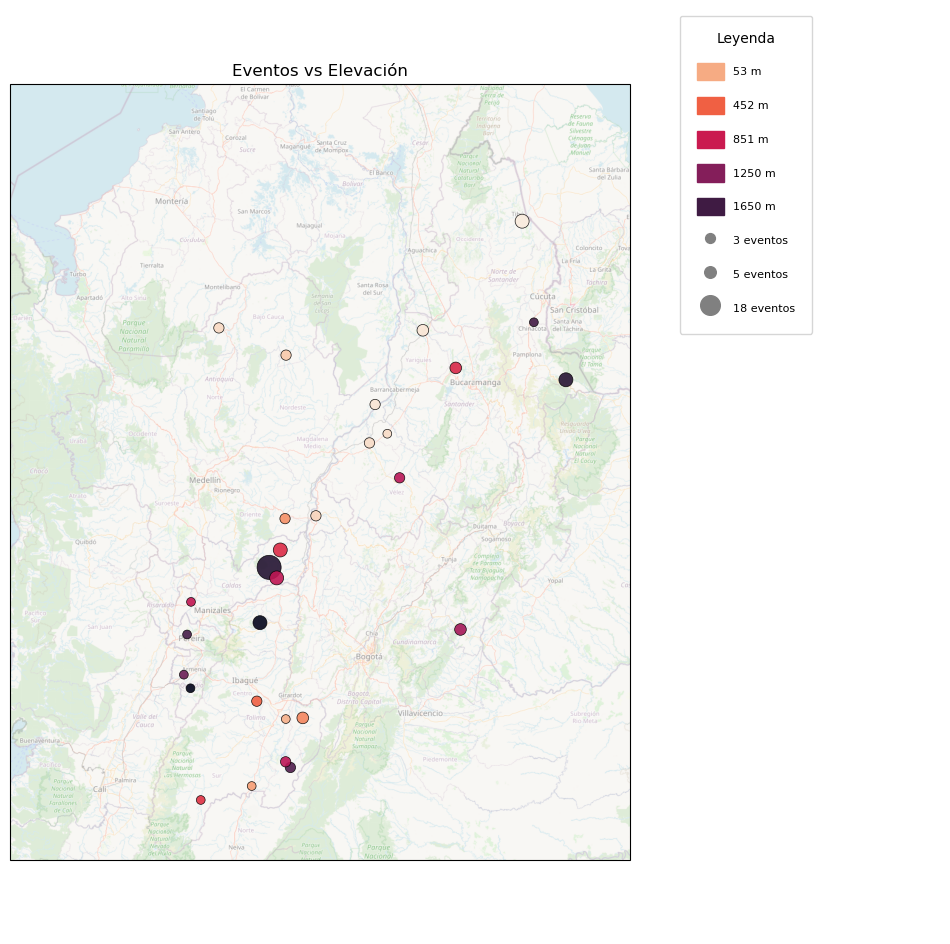

In [24]:

# Generate scatter plot
tiler = cimgt.OSM()
mercator = tiler.crs

FrecEventos_3857 = FrecEventos_4326.to_crs(epsg=3857)

# Crear figura con 2 columnas: 1 para el gráfico, 1 para la leyenda
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.5, 1.5], wspace=0.1) #una fila, dos columnas, espaciado horizonrtal de 0.5 y 
                                                                  #ratios es la proporción de cada sub con respecto al gráfico


ax0 = fig.add_subplot(gs[0],projection=mercator)
ax0.add_image(tiler, 8, alpha =0.5)

scatter = ax0.scatter(
    FrecEventos_3857.geometry.x,
    FrecEventos_3857.geometry.y,
    c=FrecEventos_3857['elevacion'],
    s=np.interp(FrecEventos_3857['eventos'], (FrecEventos_3857['eventos'].min(), FrecEventos_3857['eventos'].max()), (40, 300)),
    cmap='rocket_r',
    edgecolors='black',
    linewidths=0.5,
    alpha=0.9,
    transform=ccrs.Mercator()
)
    
ax0.set_title('Eventos vs Elevación')
ax0.set_xlabel('Longitud')
ax0.set_ylabel('Latitud')

# Subplot vacío para la leyenda en la segunda columna
ax1 = fig.add_subplot(gs[1])
ax1.axis('off')  # quitar ejes

# Crear leyenda de elevación (color)
elev_min = FrecEventos_3857['elevacion'].min()
elev_max = FrecEventos_3857['elevacion'].max()
elev_legend_vals = np.linspace(elev_min, elev_max, 5).astype(int)
elev_colors = sns.color_palette('rocket_r', len(elev_legend_vals))
elev_patches = [mpatches.Patch(color=c, label=f'{v} m') for c, v in zip(elev_colors, elev_legend_vals)]

# Crear leyenda de eventos (tamaño)
eventos_vals = sorted(FrecEventos_3857['eventos'].unique())[-3:]
eventos_sizes = np.interp(eventos_vals, (min(eventos_vals), max(eventos_vals)), (50, 200))
eventos_handles = [plt.scatter([], [], s=s, color='gray', label=f'{int(v)} eventos') for s, v in zip(eventos_sizes, eventos_vals)]

# Dibujar leyendas en el subplot
ax1.legend(handles=elev_patches + eventos_handles, title='Leyenda', fontsize=8, title_fontsize=10, loc='upper left',
           labelspacing=1.5, handlelength=2.5, handleheight=2.0, borderpad=1.5, ncol=1)

plt.show()

### Asignar elevaciones

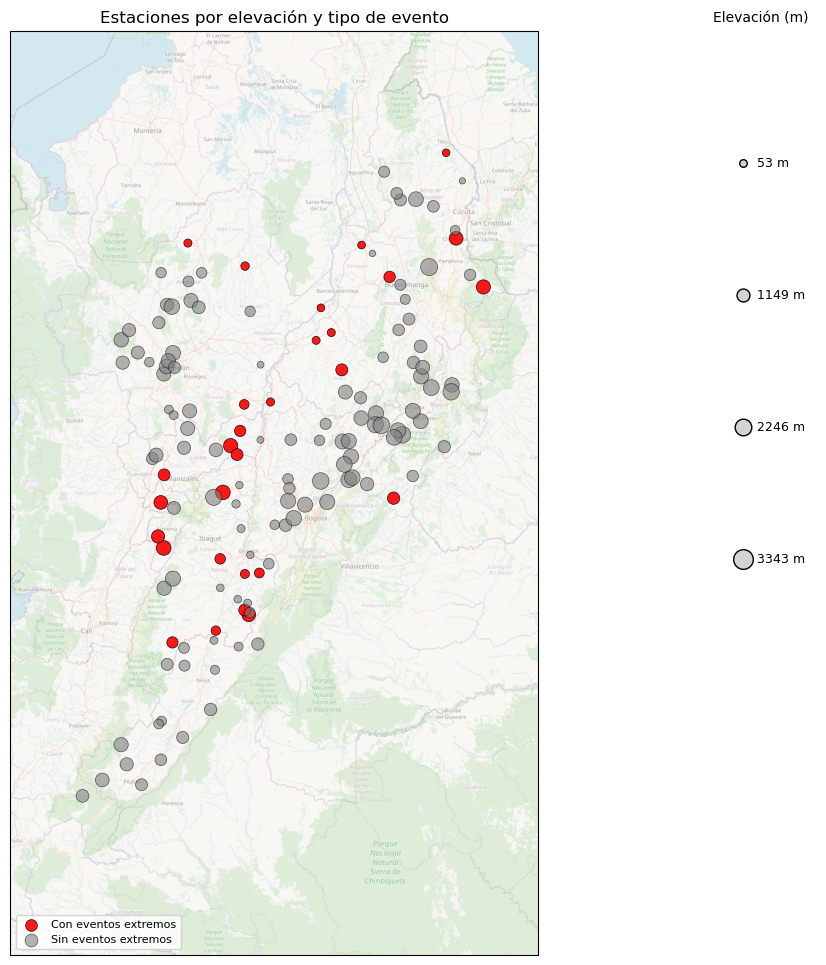

In [25]:

# Asegurar sistema de coordenadas
No_eventos_3857 = No_eventos_4326.to_crs(epsg=3857)
FrecEventos_3857 = FrecEventos_4326.to_crs(epsg=3857)

# Crear figura con 2 columnas
fig = plt.figure(figsize=(12, 12))
gs = gridspec.GridSpec(1, 2, width_ratios=[3.5, 0.5], wspace=0.1)

# Mapa base
tiler = cimgt.OSM()
mercator = tiler.crs

# Subplot principal
ax0 = fig.add_subplot(gs[0], projection=mercator)
ax0.add_image(tiler, 8, alpha=0.5)

# Escalar elevación a tamaño de puntos
elev_min = min(FrecEventos_3857['elevacion'].min(), No_eventos_3857['elevacion'].min())
elev_max = max(FrecEventos_3857['elevacion'].max(), No_eventos_3857['elevacion'].max())

size_eventos = np.interp(FrecEventos_3857['elevacion'], (elev_min, elev_max), (30, 200))
size_no_eventos = np.interp(No_eventos_3857['elevacion'], (elev_min, elev_max), (20, 150))

# Scatter eventos
ax0.scatter(
    FrecEventos_3857.geometry.x,
    FrecEventos_3857.geometry.y,
    color='red',
    s=size_eventos,
    edgecolors='black',
    linewidths=0.5,
    alpha=0.9,
    transform=mercator,
    label="Con eventos extremos"
)

# Scatter no eventos
ax0.scatter(
    No_eventos_3857.geometry.x,
    No_eventos_3857.geometry.y,
    color='gray',
    s=size_no_eventos,
    edgecolors='black',
    linewidths=0.5,
    alpha=0.6,
    transform=mercator,
    label="Sin eventos extremos"
)

# Ajustes del subplot de mapa
ax0.set_title('Estaciones por elevación y tipo de evento')
ax0.set_xlabel('Longitud')
ax0.set_ylabel('Latitud')
ax0.legend(loc='lower left', fontsize=8)

# Leyenda de colores en el subplot derecho
ax1 = fig.add_subplot(gs[1])
ax1.axis('off')

ref_elev = np.linspace(elev_min, elev_max, 4).astype(int)
ref_sizes = np.interp(ref_elev, (elev_min, elev_max), (30, 200))

for i, (elev, size) in enumerate(zip(ref_elev, ref_sizes)):
    ax1.scatter(0.5, 1 - i*0.2, s=size, color='lightgray', edgecolor='black')
    ax1.text(0.7, 1 - i*0.2, f"{elev} m", va='center', fontsize=9)

ax1.set_xlim(0, 1.5)
ax1.set_ylim(-0.2, 1.2)
ax1.set_title('Elevación (m)', fontsize=10)


plt.show()



## Asignar magnitud y dirección del viento

Se consideran estas variables para contemplar la orografia:

ECMWF/ERA5_LAND/HOURLY
Bandas: u_component_of_wind_10m, v_component_of_wind_10m
Resolución: 0.1° (~11 km)
Intervalo: horario

In [26]:
#Pasar de geotaframe a featurecollection

def gdf_to_ee_featurecollection(gdf):
    features = []
    for idx, row in gdf.iterrows():
        geom = ee.Geometry.Point([row.geometry.x, row.geometry.y])
        feature = ee.Feature(geom, {'CodigoEstacion': str(row['CodigoEstacion'])})
        features.append(feature)
    return ee.FeatureCollection(features)



In [27]:
def get_mean_wind(fc, start_date='2022-01-01', end_date='2022-12-31'):
    era5 = ee.ImageCollection('ECMWF/ERA5_LAND/HOURLY') \
        .filterDate(start_date, end_date) \
        .select(['u_component_of_wind_10m', 'v_component_of_wind_10m'])

    # Calcular media anual de u y v
    mean_u = era5.select('u_component_of_wind_10m').mean()
    mean_v = era5.select('v_component_of_wind_10m').mean()
    wind_stack = mean_u.addBands(mean_v)

    # Extraer valores
    extracted = wind_stack.sampleRegions(
        collection=fc,
        scale=1000,
        geometries=True
    )

    # Descargar como lista
    wind_dict = extracted.getInfo()['features']
    
    # Convertir a DataFrame
    datos = []
    for f in wind_dict:
        props = f['properties']
        u = props['u_component_of_wind_10m']
        v = props['v_component_of_wind_10m']
        codigo = props['CodigoEstacion']
        mag = np.sqrt(u**2 + v**2)
        dir_rad = np.arctan2(-u, -v)  # Dirección desde la que viene el viento
        dir_deg = (np.degrees(dir_rad) + 360) % 360
        #datos.append({'CodigoEstacion': codigo, 'u': u, 'v': v, 'magnitud_viento': mag, 'direccion_viento': dir_deg})
        datos.append({'CodigoEstacion': codigo, 'magnitud_viento': mag, 'direccion_viento': dir_deg})
    
    return pd.DataFrame(datos)


In [28]:
fc_eventos = gdf_to_ee_featurecollection(FrecEventos_4326)
fc_no_eventos = gdf_to_ee_featurecollection(No_eventos_4326)

df_viento_eventos = get_mean_wind(fc_eventos)
df_viento_no_eventos = get_mean_wind(fc_no_eventos)

FrecEventos_4326["CodigoEstacion"] = FrecEventos_4326["CodigoEstacion"].astype(str)
df_viento_eventos["CodigoEstacion"] = df_viento_eventos["CodigoEstacion"].astype(str)

No_eventos_4326["CodigoEstacion"] = No_eventos_4326["CodigoEstacion"].astype(str)
df_viento_no_eventos["CodigoEstacion"] = df_viento_no_eventos["CodigoEstacion"].astype(str)

#Eliminar los valores de las columnas por si ya estaban llenas
cols_viento = ['magnitud_viento', 'direccion_viento']
FrecEventos_4326 = FrecEventos_4326.drop(columns=[c for c in cols_viento if c in FrecEventos_4326.columns])
No_eventos_4326 = No_eventos_4326.drop(columns=[c for c in cols_viento if c in No_eventos_4326.columns])

FrecEventos_4326ev = FrecEventos_4326.merge(df_viento_eventos, on='CodigoEstacion', how='left')
No_eventos_4326ev = No_eventos_4326.merge(df_viento_no_eventos, on='CodigoEstacion', how='left')


In [29]:
No_eventos_4326ev.head(10)



,CodigoEstacion,geometry,lat,lon,elevacion,magnitud_viento,direccion_viento
0,11070030,POINT (-76.15861 6.53944),6.539444,-76.158611,2307,0.338040,278.810243
1,11075020,POINT (-76.14331 6.29831),6.298306,-76.143306,1884,0.205033,306.321484
2,11110020,POINT (-76.075 6.6425),6.642500,-76.075000,1870,0.265424,286.537033
3,16010020,POINT (-72.60139 7.69722),7.697222,-72.601389,775,0.357664,126.100262
4,16020250,POINT (-72.52456 8.21917),8.219167,-72.524556,71,0.325323,78.495120
5,16030080,POINT (-72.8325 7.95028),7.950278,-72.832500,1359,0.537442,89.467574
6,16030100,POINT (-73.01861 8.02528),8.025278,-73.018611,2461,0.732982,72.754893
7,16050100,POINT (-73.18375 8.01747),8.017472,-73.183750,1471,0.653406,63.937594
8,16055010,POINT (-73.3575 8.31528),8.315278,-73.357500,1169,0.599145,52.237667
9,16055040,POINT (-73.22306 8.08722),8.087222,-73.223056,1386,0.791134,61.338647


## Asignar temperatura media anual

ERA5-Land Daily Aggregated - Reanálisis climático del ECMWF: temperature_2m - temperatura en K --> °C

In [30]:
def get_mean_temperature(fc, start_date='2022-01-01', end_date='2022-12-31'):
    # Cargar colección diaria de ERA5-Land
    era5_daily = ee.ImageCollection('ECMWF/ERA5_LAND/DAILY_AGGR') \
        .filterDate(start_date, end_date) \
        .select('temperature_2m')
    
    # Calcular la media anual de temperatura 2m
    mean_temp = era5_daily.mean()
    
    # Extraer valores en las estaciones
    extracted = mean_temp.sampleRegions(
        collection=fc,
        scale=1000,
        geometries=True
    )
    
    # Descargar como lista
    temp_dict = extracted.getInfo()['features']
    
    # Convertir a DataFrame
    datos = []
    for f in temp_dict:
        props = f['properties']
        temp_k = props['temperature_2m']  # Temperatura en Kelvin
        codigo = props['CodigoEstacion']
        temp_c = temp_k - 273.15  # Convertir a °C
        datos.append({'CodigoEstacion': codigo, 'temp_media_anual_C': temp_c})
    
    return pd.DataFrame(datos)


In [31]:
FrecEventos_4326ev["CodigoEstacion"] = FrecEventos_4326ev["CodigoEstacion"].astype(str)
No_eventos_4326ev["CodigoEstacion"] = No_eventos_4326ev["CodigoEstacion"].astype(str)

fc_eventost = gdf_to_ee_featurecollection(FrecEventos_4326ev)
fc_no_eventost = gdf_to_ee_featurecollection(No_eventos_4326ev)

df_temp_eventos = get_mean_temperature(fc_eventost)
df_temp_no_eventos = get_mean_temperature(fc_no_eventost)

# Borrar si existía ya la columna de temperatura
cols_temp = ['temp_media_anual_C']
FrecEventos_4326ev = FrecEventos_4326ev.drop(columns=[c for c in cols_temp if c in FrecEventos_4326ev.columns])
No_eventos_4326ev = No_eventos_4326ev.drop(columns=[c for c in cols_temp if c in No_eventos_4326ev.columns])

# Hacer merge para añadir temperatura
FrecEventos_4326evt = FrecEventos_4326ev.merge(df_temp_eventos, on='CodigoEstacion', how='left')
No_eventos_4326evt = No_eventos_4326ev.merge(df_temp_no_eventos, on='CodigoEstacion', how='left')

In [32]:
FrecEventos_4326evt.head(10)

,CodigoEstacion,eventos,geometry,lat,lon,elevacion,magnitud_viento,direccion_viento,temp_media_anual_C
0,23055040,18,POINT (-74.99293 5.41829),5.418288,-74.992928,1500,0.146534,206.401286,20.077479
1,37020030,5,POINT (-72.30028 7.09889),7.098889,-72.300278,1478,0.140122,253.335274,16.332506
2,21250500,5,POINT (-75.07586 4.92189),4.921889,-75.075861,1634,0.429306,117.435163,16.900376
3,23020100,5,POINT (-74.92444 5.32389),5.323889,-74.924444,899,0.599751,246.939662,23.132263
4,23050250,5,POINT (-74.89169 5.57447),5.574472,-74.891694,766,0.433478,287.721419,23.313634
5,16030030,5,POINT (-72.69744 8.51494),8.514944,-72.697444,53,0.177163,333.866916,25.533778
6,35070180,3,POINT (-73.25675 4.86078),4.860778,-73.256750,991,0.010139,341.650274,17.744701
7,21160030,3,POINT (-74.68761 4.06639),4.066389,-74.687611,457,0.249724,34.825331,22.515924
8,23190440,3,POINT (-73.29972 7.205),7.205000,-73.299722,785,0.220792,146.515777,21.529874
9,23180050,3,POINT (-73.59806 7.54139),7.541389,-73.598056,73,0.178437,63.948411,25.634052


## Cobertura
GOOGLE/DYNAMICWORLD/V1
Variable categorica, se binariza, en algunas zonas carece de información: 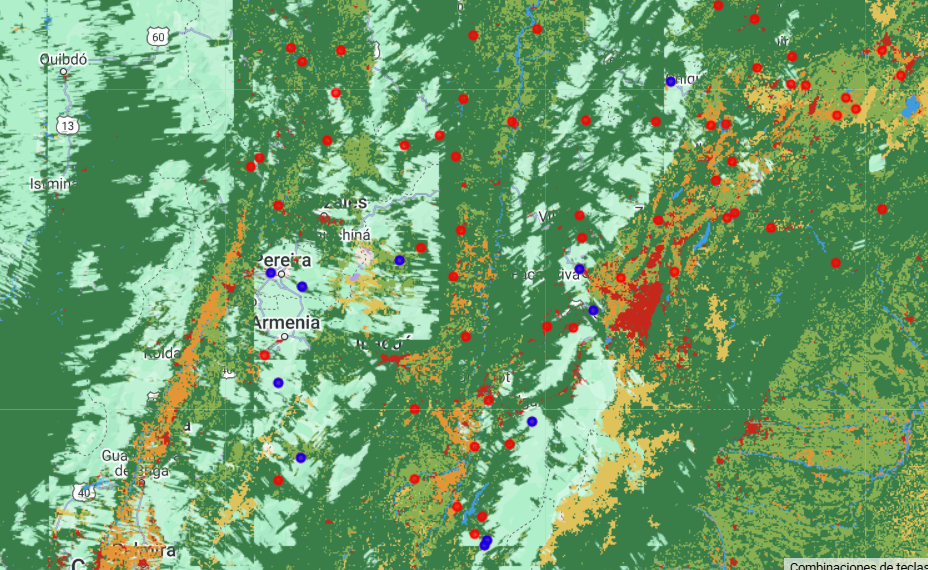

Al final se decidió con Modis


In [33]:
def get_modis_landcover_onehot(gdf):
    # Mapeo de clases MODIS a categorías agrupadas
    clase_a_categoria = {
        0: 'bosque',
        1: 'bosque',
        2: 'bosque',
        3: 'bosque',
        4: 'sabana',
        5: 'sabana',
        6: 'sabana',
        7: 'sabana',
        8: 'sabana',
        9: 'tierra_desarrollada',
        10: 'tierra_desarrollada',
        11: 'tierra_desarrollada',
        12: 'tierra_desarrollada',
        13: 'sabana',
        14: 'hielo_nieve',
        15: 'agua',
        16: 'inundacion_estacional',
        17: 'sin_datos'
    }

    categorias = list(set(clase_a_categoria.values()))  # categorías únicas

    # Cargar imagen MODIS para el año 2022
    modis = ee.ImageCollection('MODIS/061/MCD12Q1') \
        .filter(ee.Filter.date('2022-01-01', '2022-12-31')) \
        .first() \
        .select('LC_Type1')

    # Convertir GeoDataFrame a FeatureCollection
    ee_features = []
    for _, row in gdf.iterrows():
        geom = ee.Geometry.Point([row['lon'], row['lat']])
        feature = ee.Feature(geom, {'CodigoEstacion': str(row['CodigoEstacion'])})
        ee_features.append(feature)
    fc = ee.FeatureCollection(ee_features)

    # Samplear valores MODIS
    sampled = modis.sampleRegions(
        collection=fc,
        scale=500,
        geometries=True
    )

    # Obtener resultados
    features = sampled.getInfo()['features']

    # Procesar resultados
    datos = []
    sin_datos = []
    for f in features:
        props = f['properties']
        codigo = props['CodigoEstacion']
        clase = int(props['LC_Type1'])
        categoria = clase_a_categoria.get(clase, 'desconocido')

        fila = {'CodigoEstacion': codigo}
        for cat in categorias:
            fila[f'cobertura_{cat}'] = 1 if cat == categoria else 0
        fila['cobertura_dominante'] = categoria
        datos.append(fila)

        if categoria == 'sin_datos':
            sin_datos.append({'CodigoEstacion': codigo})

    df = pd.DataFrame(datos)
    df_sin_datos = pd.DataFrame(sin_datos)

    return df, df_sin_datos


In [34]:
# Obtener DataFrames de cobertura MODIS y estaciones sin datos
df_lc_eventos, sin_datos_eventos = get_modis_landcover_onehot(FrecEventos_4326evt)
df_lc_no_eventos, sin_datos_no_eventos = get_modis_landcover_onehot(No_eventos_4326evt)

# Asegurar tipo string
for df in [df_lc_eventos, df_lc_no_eventos, FrecEventos_4326evt, No_eventos_4326evt]:
    df["CodigoEstacion"] = df["CodigoEstacion"].astype(str)

# Eliminar columnas anteriores de cobertura
cols_cobertura = [col for col in FrecEventos_4326evt.columns if col.startswith('cobertura_')]
FrecEventos_4326evt = FrecEventos_4326evt.drop(columns=cols_cobertura, errors='ignore')
No_eventos_4326evt = No_eventos_4326evt.drop(columns=cols_cobertura, errors='ignore')

# Hacer merge para añadir la nueva cobertura
FrecEventos_4326evtc = FrecEventos_4326evt.merge(df_lc_eventos, on='CodigoEstacion', how='left')
No_eventos_4326evtc = No_eventos_4326evt.merge(df_lc_no_eventos, on='CodigoEstacion', how='left')

# Mostrar si hay estaciones sin datos
print("Estaciones con 'sin datos' en eventos:", sin_datos_eventos)
print("Estaciones con 'sin datos' en no eventos:", sin_datos_no_eventos)




Estaciones con 'sin datos' en eventos: Empty DataFrame
Columns: []
Index: []
Estaciones con 'sin datos' en no eventos: Empty DataFrame
Columns: []
Index: []


In [35]:
FrecEventos_4326evtc.head(5)

,CodigoEstacion,eventos,geometry,lat,lon,elevacion,magnitud_viento,direccion_viento,temp_media_anual_C,cobertura_bosque,cobertura_sabana,cobertura_tierra_desarrollada,cobertura_inundacion_estacional,cobertura_hielo_nieve,cobertura_sin_datos,cobertura_agua,cobertura_dominante
0,23055040,18,POINT (-74.99293 5.41829),5.418288,-74.992928,1500,0.146534,206.401286,20.077479,0,0,1,0,0,0,0,tierra_desarrollada
1,37020030,5,POINT (-72.30028 7.09889),7.098889,-72.300278,1478,0.140122,253.335274,16.332506,0,1,0,0,0,0,0,sabana
2,21250500,5,POINT (-75.07586 4.92189),4.921889,-75.075861,1634,0.429306,117.435163,16.900376,0,1,0,0,0,0,0,sabana
3,23020100,5,POINT (-74.92444 5.32389),5.323889,-74.924444,899,0.599751,246.939662,23.132263,0,1,0,0,0,0,0,sabana
4,23050250,5,POINT (-74.89169 5.57447),5.574472,-74.891694,766,0.433478,287.721419,23.313634,0,1,0,0,0,0,0,sabana


## Ocurre o no ocurre? Modelo Lineal Generalizado (GML)
### Regresión Logística
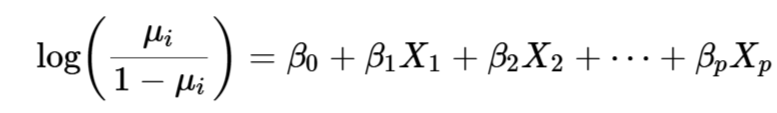


In [36]:
# Preparación de variables
# El evento se tranforma en binario
# Se separan los datos para validación cruzada 80/20

VariablesEventos = FrecEventos_4326evtc.drop(columns=['eventos'])
VariablesEventos['ocurrencia'] = 1
n_70 = int(len(VariablesEventos)*0.8)
VariablesEventos_shuffled = VariablesEventos.sample(frac=1, random_state=42).reset_index(drop=True) #Se organizan las filas de manera random
VariablesEventos_ajuste = VariablesEventos_shuffled.iloc[:n_70]
VariablesEventos_verificacion = VariablesEventos_shuffled.iloc[n_70:]

d_70= int(len(No_eventos_4326evtc)*0.8)
No_eventos_4326evtc['ocurrencia'] = 0
No_eventos_shuffled = No_eventos_4326evtc.sample(frac=1, random_state=42).reset_index(drop=True) #Se organizan las filas de manera random
No_eventos_ajuste = No_eventos_shuffled.iloc[:n_70]
No_eventos_verificacion = No_eventos_shuffled.iloc[n_70:]

Estaciones_ajuste = gpd.GeoDataFrame(pd.concat([VariablesEventos_ajuste, No_eventos_ajuste], ignore_index=True)) #ignore_index=True reinicia el indice para evitar duplicados
Estaciones_verificacion= gpd.GeoDataFrame(pd.concat([VariablesEventos_verificacion, No_eventos_verificacion], ignore_index=True))


# Se evita la multicolinealidad
Estaciones_ajuste = Estaciones_ajuste.drop(columns=['cobertura_sin_datos', 'cobertura_dominante'])
Estaciones_verificacion = Estaciones_verificacion.drop(columns=['cobertura_sin_datos','cobertura_dominante'])


##### Nota
La suma de todas las columnas dummy para una fila siempre da 1
* Es decir, son linealmente dependientes
* Genera multicolinealidad perfecta

La solución para esa multicolinealidad es crear una variable base, esta se elimina.

La multicolinealidad es un fenómeno en modelos estadísticos —especialmente en regresión lineal— que ocurre cuando dos o más variables independientes están altamente correlacionadas entre sí. En otras palabras, una variable puede predecirse en gran medida con una combinación lineal de las otras. 
Este fenomeno puede provocar errores númericos o que los coeficientes estimados sean muy grandes o inestables. 

La suma de todas esas columnas es siempre igual a 1.
Eso significa que una de las columnas se puede deducir a partir del resto.
→ Eso es multicolinealidad perfecta.

Al eliminar una variable se rompe la independencia linea y se evita la multicolinealidad. Los coeficientes de las demás clases se interpretan en comparación con esa clase base.

Ej: en el caso de ser 3 categorias, al yo conocer 2 de ellas, ya puedo estimar la tercera, no se aporta información, es redundante

In [37]:
# Agregar constante
V_indep = sm.add_constant(Estaciones_ajuste[['elevacion','cobertura_tierra_desarrollada']])  # añade la constante (intercepto)

V_dep = Estaciones_ajuste['ocurrencia']

# Ajuste del modelo
modelo = sm.Logit(V_dep, V_indep).fit()
print(modelo.summary())

Optimization terminated successfully.
         Current function value: 0.497258
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:             ocurrencia   No. Observations:                   46
Model:                          Logit   Df Residuals:                       43
Method:                           MLE   Df Model:                            2
Date:                Tue, 27 May 2025   Pseudo R-squ.:                  0.2826
Time:                        15:25:21   Log-Likelihood:                -22.874
converged:                       True   LL-Null:                       -31.885
Covariance Type:            nonrobust   LLR p-value:                 0.0001221
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                             2.9364      0.947      3.102      0.

### Otras iteraciones	
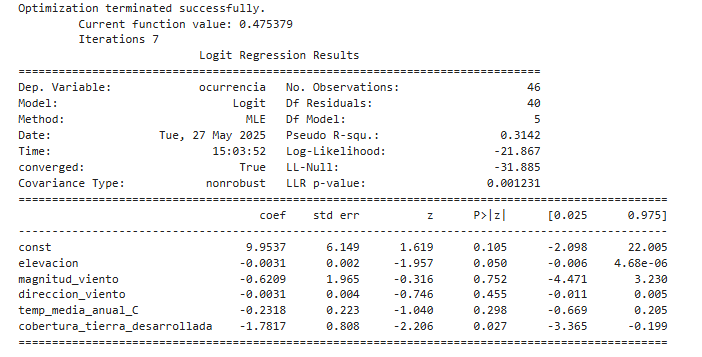
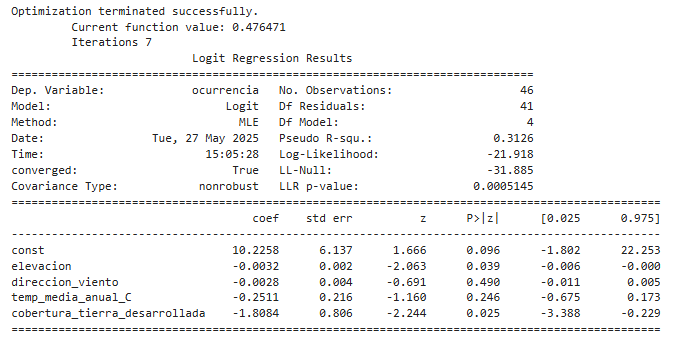
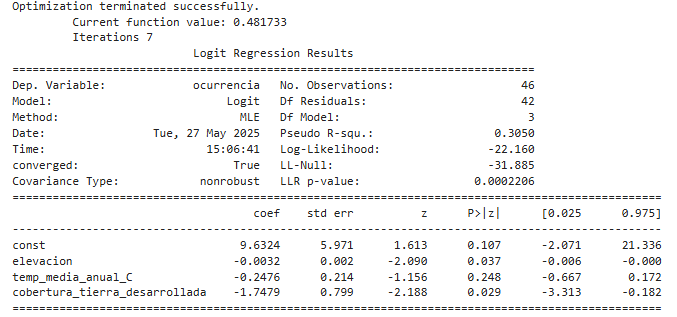
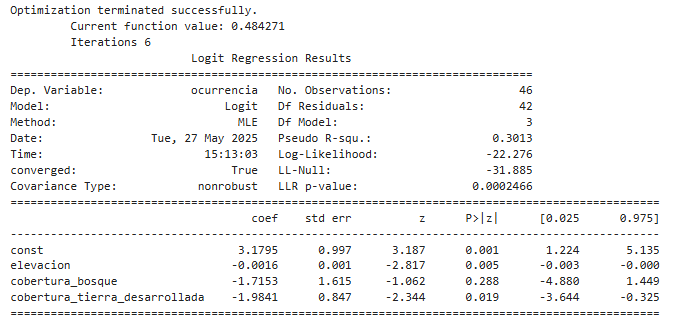

### Pendiente: Incluir dentro del análsiis otras variables que puedan representar mejor el fenomeno: 
Advección de humedad por ejemplo: Maagnitud del viento x humedad relativa